In [2]:
%pip install pandas matplotlib numpy

  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.9 MB 11.4 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.9 MB 11.2 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 11.4 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 10.7 MB/s  0:00:00
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----------- ---------------------------- 2.4/8.3 MB 11.7 MB/s eta 0:00:01
   ---------------------- ----------------- 4.7/8.3 MB 11.8 MB/s eta 0:00:01
   --------------------------------- ------ 7.1/8.3 MB 11.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 11.3 MB/s  0:00:00
Using cached numpy-2.4.4-cp314-cp314

In [ ]:
import pandas as pd
from collections import defaultdict

def load_bm25_results(file_path):
    # load CSV
    df = pd.read_csv(file_path)
    
    # initialize dictionary
    bm25_rankings = defaultdict(list)
    

    df = df.sort_values(by=["query_id", "rank"])
    
    # put in the dictionary
    for qid, group in df.groupby("query_id"):
        bm25_rankings[qid] = group["doc_id"].tolist()
        
    return bm25_rankings

# load BM25 
bm25_results = load_bm25_results("bm25_rankings_full.csv")

# test
sample_qid = list(bm25_results.keys())[0]
print(f"Query ID: {sample_qid}")
print(f"Top 3 Docs: {bm25_results[sample_qid][:3]}")

Query ID: test_1
Top 3 Docs: ['58C6D0A1C6DAD01E3F0F1748DC472C3DDCC07E43', '5BC1631D896899D03E7D8DD2296C21656DD169FF', 'E88EDBB9A31F8B7C70FB3BA48136D9C3CD6767AC']


In [ ]:
#baseline_b mpnet
def load_rankings(file_path):
    df = pd.read_csv(file_path)
    rankings = defaultdict(list)
    
    
    df = df.sort_values(by=["query_id", "rank"])
    
    for qid, group in df.groupby("query_id"):
        rankings[qid] = group["doc_id"].tolist()
        
    return rankings

# load the result of Dense 
dense_results_mpnet = load_rankings("dense_results_mpnet.csv")

# validate Dense 
sample_qid = list(dense_results_mpnet.keys())[0]
print(f"Dense Query ID: {sample_qid}")
print(f"Dense Top 3 Docs: {dense_results_mpnet[sample_qid][:3]}")

Dense Query ID: test_1
Dense Top 3 Docs: ['5B37710FE7BBD6EFB842FEB7B49B036302E18F81', 'B2593108FA446C4B4B0EF5ADC2CD5D9585B0B63C', '58C6D0A1C6DAD01E3F0F1748DC472C3DDCC07E43']


In [ ]:
#baselin_b mini
def load_rankings(file_path):
    df = pd.read_csv(file_path)
    rankings = defaultdict(list)
    

    df = df.sort_values(by=["query_id", "rank"])
    
    for qid, group in df.groupby("query_id"):
        rankings[qid] = group["doc_id"].tolist()
        
    return rankings

# load the result of Dense 
dense_results_mini = load_rankings("dense_results_minilm.csv")

# validate Dense
sample_qid = list(dense_results_mini.keys())[0]
print(f"Dense Query ID: {sample_qid}")
print(f"Dense Top 3 Docs: {dense_results_mini[sample_qid][:3]}")

Dense Query ID: test_1
Dense Top 3 Docs: ['323D19F0757433758D1743B0A62DACC98D286EC5', 'C038BA342A00562BCB7A569E4E2ACB7349C9CEF9', '58C6D0A1C6DAD01E3F0F1748DC472C3DDCC07E43']


In [ ]:
#BM25 + mpnet
def run_rrf(bm25_ranks, dense_ranks, k=60):
    hybrid_results = {}
    
    # get all query_id
    all_qids = set(bm25_ranks.keys()) | set(dense_ranks.keys())
    
    for qid in all_qids:
        rrf_scores = defaultdict(float)
        
        # deal with the rank of BM25 
        for i, doc_id in enumerate(bm25_ranks.get(qid, []), start=1):
            rrf_scores[doc_id] += 1 / (k + i)
            
        # deal with the rank of Dense 
        for i, doc_id in enumerate(dense_ranks.get(qid, []), start=1):
            rrf_scores[doc_id] += 1 / (k + i)
            
        # according to RRF score, from high to low
        sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
        
        # get sorted doc_id
        hybrid_results[qid] = [doc for doc, score in sorted_docs]
        
    return hybrid_results


hybrid_results_mpnet = run_rrf(bm25_results, dense_results_mpnet)


print(f"Hybrid Top 3 for {sample_qid}: {hybrid_results_mpnet[sample_qid][:3]}")

Hybrid Top 3 for test_1: ['58C6D0A1C6DAD01E3F0F1748DC472C3DDCC07E43', 'B2593108FA446C4B4B0EF5ADC2CD5D9585B0B63C', '5BC1631D896899D03E7D8DD2296C21656DD169FF']


In [ ]:
#BM25 + mini
def run_rrf(bm25_ranks, dense_ranks, k=60):
    hybrid_results = {}
    
    
    all_qids = set(bm25_ranks.keys()) | set(dense_ranks.keys())
    
    for qid in all_qids:
        rrf_scores = defaultdict(float)
        
      
        for i, doc_id in enumerate(bm25_ranks.get(qid, []), start=1):
            rrf_scores[doc_id] += 1 / (k + i)
            
        
        for i, doc_id in enumerate(dense_ranks.get(qid, []), start=1):
            rrf_scores[doc_id] += 1 / (k + i)
            
        
        sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
        
        
        hybrid_results[qid] = [doc for doc, score in sorted_docs]
        
    return hybrid_results


hybrid_results_mini = run_rrf(bm25_results, dense_results_mini)


print(f"Hybrid Top 3 for {sample_qid}: {hybrid_results_mini[sample_qid][:3]}")

Hybrid Top 3 for test_1: ['58C6D0A1C6DAD01E3F0F1748DC472C3DDCC07E43', '120CAE8361AE4E0B6FE4D6F0D32EEE9517F11190', 'B2593108FA446C4B4B0EF5ADC2CD5D9585B0B63C']


In [ ]:
import csv

def save_hybrid_results(hybrid_results, filename="hybrid_results_rrf.csv"):
    with open(filename, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(["query_id", "rank", "doc_id", "score"])
        
        for qid, doc_list in hybrid_results.items():
            # get the previous 100 data
            for i, doc_id in enumerate(doc_list[:100], start=1):
                writer.writerow([qid, i, doc_id, 0])
    print(f"✅ 成功儲存 Hybrid 結果至: {filename}")

save_hybrid_results(hybrid_results_mpnet)

✅ 成功儲存 Hybrid 結果至: hybrid_results_rrf.csv


In [ ]:
import csv

def save_hybrid_results(hybrid_results, filename="hybrid_results_rrf.csv"):
    with open(filename, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(["query_id", "rank", "doc_id", "score"])
        
        for qid, doc_list in hybrid_results.items():
            # get the previous 100 data
            for i, doc_id in enumerate(doc_list[:100], start=1):
                writer.writerow([qid, i, doc_id, 0])
    print(f"✅ 成功儲存 Hybrid 結果至: {filename}")

save_hybrid_results(hybrid_results_mini)

✅ 成功儲存 Hybrid 結果至: hybrid_results_rrf.csv


In [ ]:
#extract qrels from BM25
#BM25 + mpnet
# A. from BM25 to get qrels
def extract_qrels(bm25_file):
    df = pd.read_csv(bm25_file)
    qrels = defaultdict(dict)
    # extract 1(correct answer)
    relevant_df = df[df['is_relevant'] == 1]
    for _, row in relevant_df.iterrows():
        qrels[str(row['query_id'])][str(row['doc_id'])] = 1
    return qrels

qrels = extract_qrels("bm25_rankings_full.csv")

# B. Dense model- mpnet
dense_results = load_rankings("dense_results_mpnet.csv")

# C. RRF
hybrid_results = run_rrf(bm25_results, dense_results)

# D. evaluation
bm25_metrics = calculate_metrics(bm25_results, qrels)
dense_metrics = calculate_metrics(dense_results_mpnet, qrels)
hybrid_metrics = calculate_metrics(hybrid_results_mpnet, qrels)


results_table = pd.DataFrame([bm25_metrics, dense_metrics, hybrid_metrics], 
                             index=["BM25", "Dense (mpnet)", "Hybrid (BM25+mpnet)"])
print(results_table)

                     Recall@1  Recall@5  Recall@10  Recall@20
BM25                 0.346667  0.626667   0.693333   0.786667
Dense (mpnet)        0.493333  0.693333   0.720000   0.813333
Hybrid (BM25+mpnet)  0.573333  0.706667   0.840000   0.906667


In [ ]:
# BM25 + mini
# A. from BM25 to get qrels
def extract_qrels(bm25_file):
    df = pd.read_csv(bm25_file)
    qrels = defaultdict(dict)
    # extract 1(correct answer)
    relevant_df = df[df['is_relevant'] == 1]
    for _, row in relevant_df.iterrows():
        qrels[str(row['query_id'])][str(row['doc_id'])] = 1
    return qrels

qrels = extract_qrels("bm25_rankings_full.csv")

# B.  Dense model- mnilim
dense_results = load_rankings("dense_results_minilm.csv")

# C. RRF
hybrid_results = run_rrf(bm25_results, dense_results)

# D. evaluation
bm25_metrics = calculate_metrics(bm25_results, qrels)
dense_metrics = calculate_metrics(dense_results_mini, qrels)
hybrid_metrics = calculate_metrics(hybrid_results_mini, qrels)

results_table = pd.DataFrame([bm25_metrics, dense_metrics, hybrid_metrics], 
                             index=["BM25", "Dense (mini)", "Hybrid (BM25+mini)"])
print(results_table)

                    Recall@1  Recall@5  Recall@10  Recall@20
BM25                0.346667  0.626667   0.693333   0.786667
Dense (mini)        0.506667  0.666667   0.760000   0.786667
Hybrid (BM25+mini)  0.520000  0.653333   0.800000   0.840000


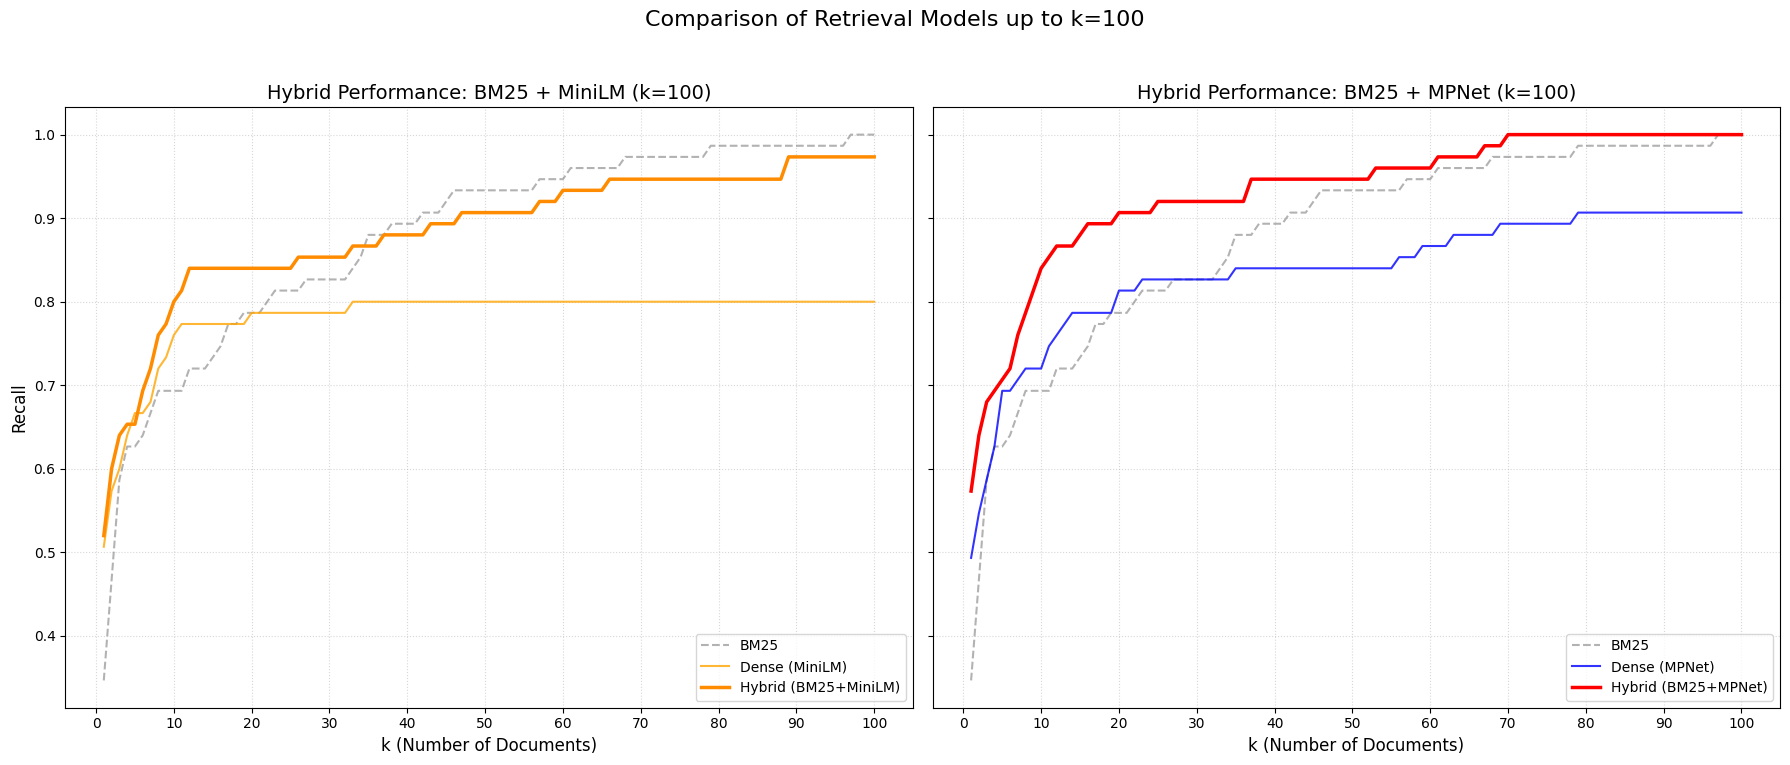

In [37]:
import matplotlib.pyplot as plt

def plot_combined_comparison_k100(bm25_res, mini_res, mpnet_res, hybrid_mini, hybrid_mpnet, qrels, max_k=100):
    ks = list(range(1, max_k + 1))
    
    # 計算各個 k 的 Recall 數據
    bm25_y = [calculate_metrics(bm25_res, qrels, k_list=[k])[f"Recall@{k}"] for k in ks]
    mini_y = [calculate_metrics(mini_res, qrels, k_list=[k])[f"Recall@{k}"] for k in ks]
    mpnet_y = [calculate_metrics(mpnet_res, qrels, k_list=[k])[f"Recall@{k}"] for k in ks]
    h_mini_y = [calculate_metrics(hybrid_mini, qrels, k_list=[k])[f"Recall@{k}"] for k in ks]
    h_mpnet_y = [calculate_metrics(hybrid_mpnet, qrels, k_list=[k])[f"Recall@{k}"] for k in ks]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

    # 左圖：MiniLM 系列 (k=100)
    ax1.plot(ks, bm25_y, label='BM25', linestyle='--', color='gray', alpha=0.6)
    ax1.plot(ks, mini_y, label='Dense (MiniLM)', linestyle='-', color='orange', alpha=0.8)
    ax1.plot(ks, h_mini_y, label='Hybrid (BM25+MiniLM)', linewidth=2.5, color='darkorange')
    ax1.set_title('Hybrid Performance: BM25 + MiniLM (k=100)', fontsize=14)
    ax1.set_xlabel('k (Number of Documents)', fontsize=12)
    ax1.set_ylabel('Recall', fontsize=12)
    ax1.set_xticks(range(0, 101, 10)) # 每 10 個點標註一次
    ax1.legend(loc='lower right')
    ax1.grid(True, which='both', linestyle=':', alpha=0.5)

    # 右圖：MPNet 系列 (k=100)
    ax2.plot(ks, bm25_y, label='BM25', linestyle='--', color='gray', alpha=0.6)
    ax2.plot(ks, mpnet_y, label='Dense (MPNet)', linestyle='-', color='blue', alpha=0.8)
    ax2.plot(ks, h_mpnet_y, label='Hybrid (BM25+MPNet)', linewidth=2.5, color='red')
    ax2.set_title('Hybrid Performance: BM25 + MPNet (k=100)', fontsize=14)
    ax2.set_xlabel('k (Number of Documents)', fontsize=12)
    ax2.set_xticks(range(0, 101, 10))
    ax2.legend(loc='lower right')
    ax2.grid(True, which='both', linestyle=':', alpha=0.5)

    plt.suptitle('Comparison of Retrieval Models up to k=100', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # 儲存新圖片
    plt.savefig('hybrid_model_comparison_k100.png', dpi=300)
    plt.show()

# 執行繪圖
plot_combined_comparison_k100(bm25_results, dense_results_mini, dense_results_mpnet, 
                              hybrid_results_mini, hybrid_results_mpnet, qrels)

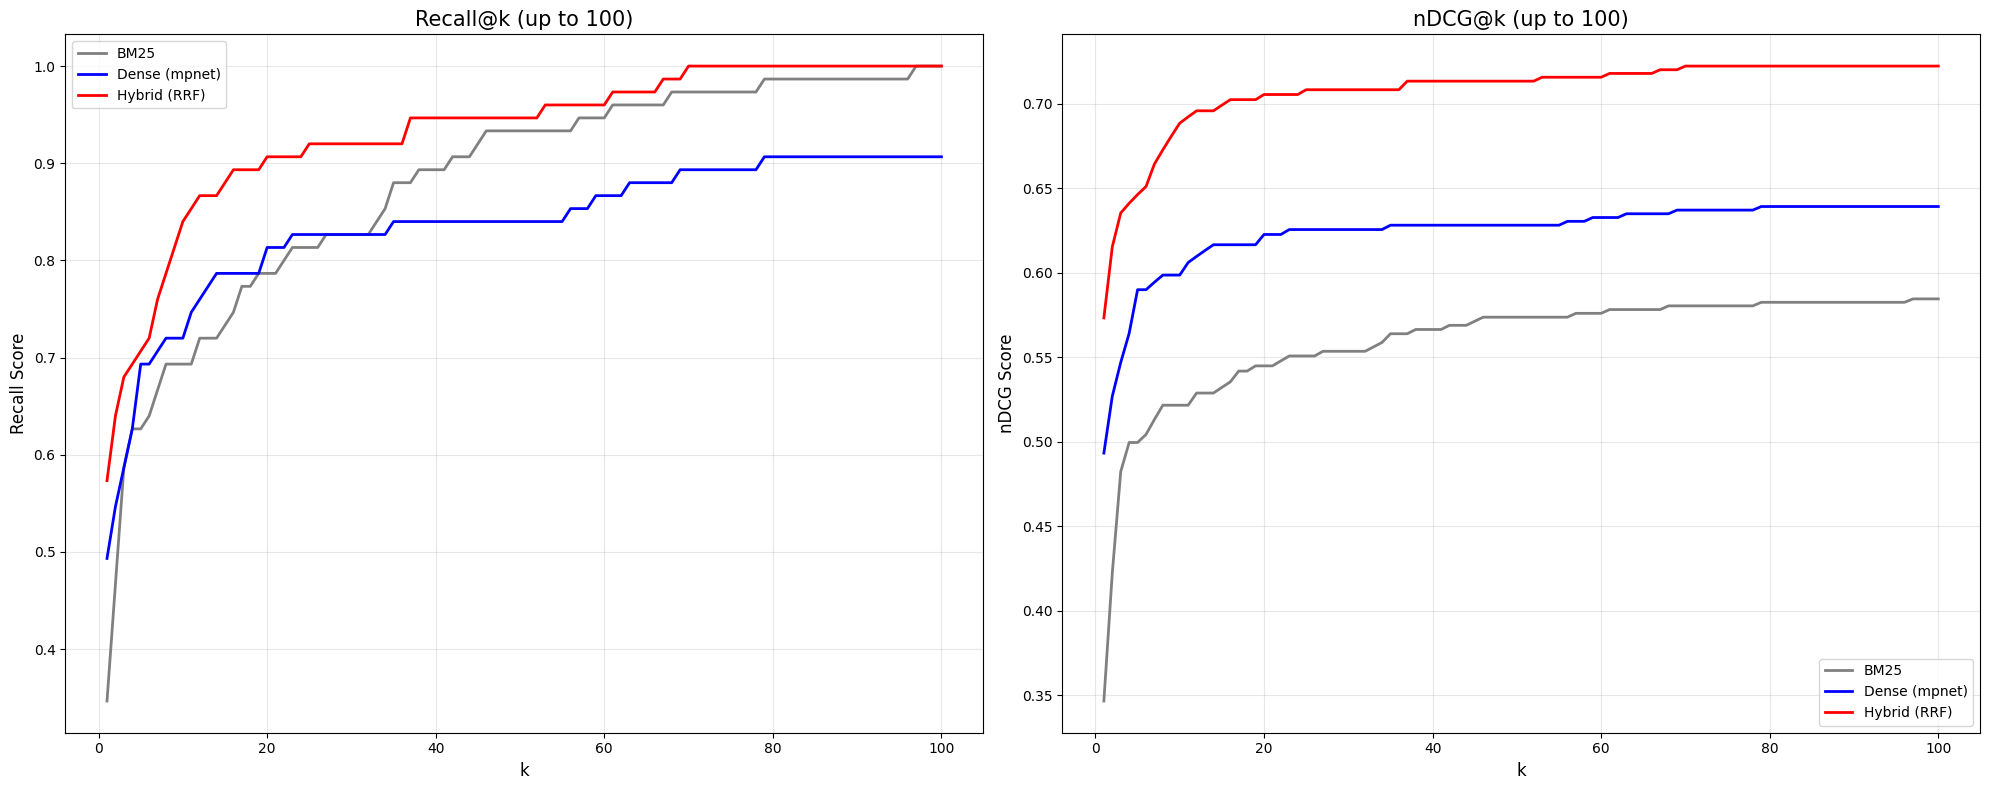

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_ndcg(results, qrels, k):
    ndcgs = []
    for qid, pred_docs in results.items():
        if qid not in qrels: continue
        
        
        actual_relevance = qrels[qid] 
        
        
        dcg = 0
        for i, doc_id in enumerate(pred_docs[:k]):
            rel = actual_relevance.get(doc_id, 0)
            dcg += (2**rel - 1) / np.log2(i + 2)
        

        idcg = 0
        sorted_rels = sorted(actual_relevance.values(), reverse=True)
        for i, rel in enumerate(sorted_rels[:k]):
            idcg += (2**rel - 1) / np.log2(i + 2)
            
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcgs)

def plot_comprehensive_metrics(all_results, qrels, max_k=100):
    ks = list(range(1, max_k + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    colors = {'BM25': 'gray', 'Dense (mpnet)': 'blue', 'Hybrid (RRF)': 'red'}

    for label, res in all_results.items():
        
        recalls = [calculate_metrics(res, qrels, k_list=[k])[f"Recall@{k}"] for k in ks]
        
        ndcgs = [calculate_ndcg(res, qrels, k) for k in ks]
        
        color = colors.get(label, None)
        ax1.plot(ks, recalls, label=f'{label}', color=color, linewidth=2)
        ax2.plot(ks, ndcgs, label=f'{label}', color=color, linewidth=2)

    
    ax1.set_title('Recall@k (up to 100)', fontsize=15)
    ax1.set_xlabel('k', fontsize=12)
    ax1.set_ylabel('Recall Score', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    
    ax2.set_title('nDCG@k (up to 100)', fontsize=15)
    ax2.set_xlabel('k', fontsize=12)
    ax2.set_ylabel('nDCG Score', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('evaluation_metrics_mpnet.png', dpi=300)
    plt.show()


plot_comprehensive_metrics({
    "BM25": bm25_results,
    "Dense (mpnet)": dense_results_mpnet,
    "Hybrid (RRF)": hybrid_results_mpnet
}, qrels)

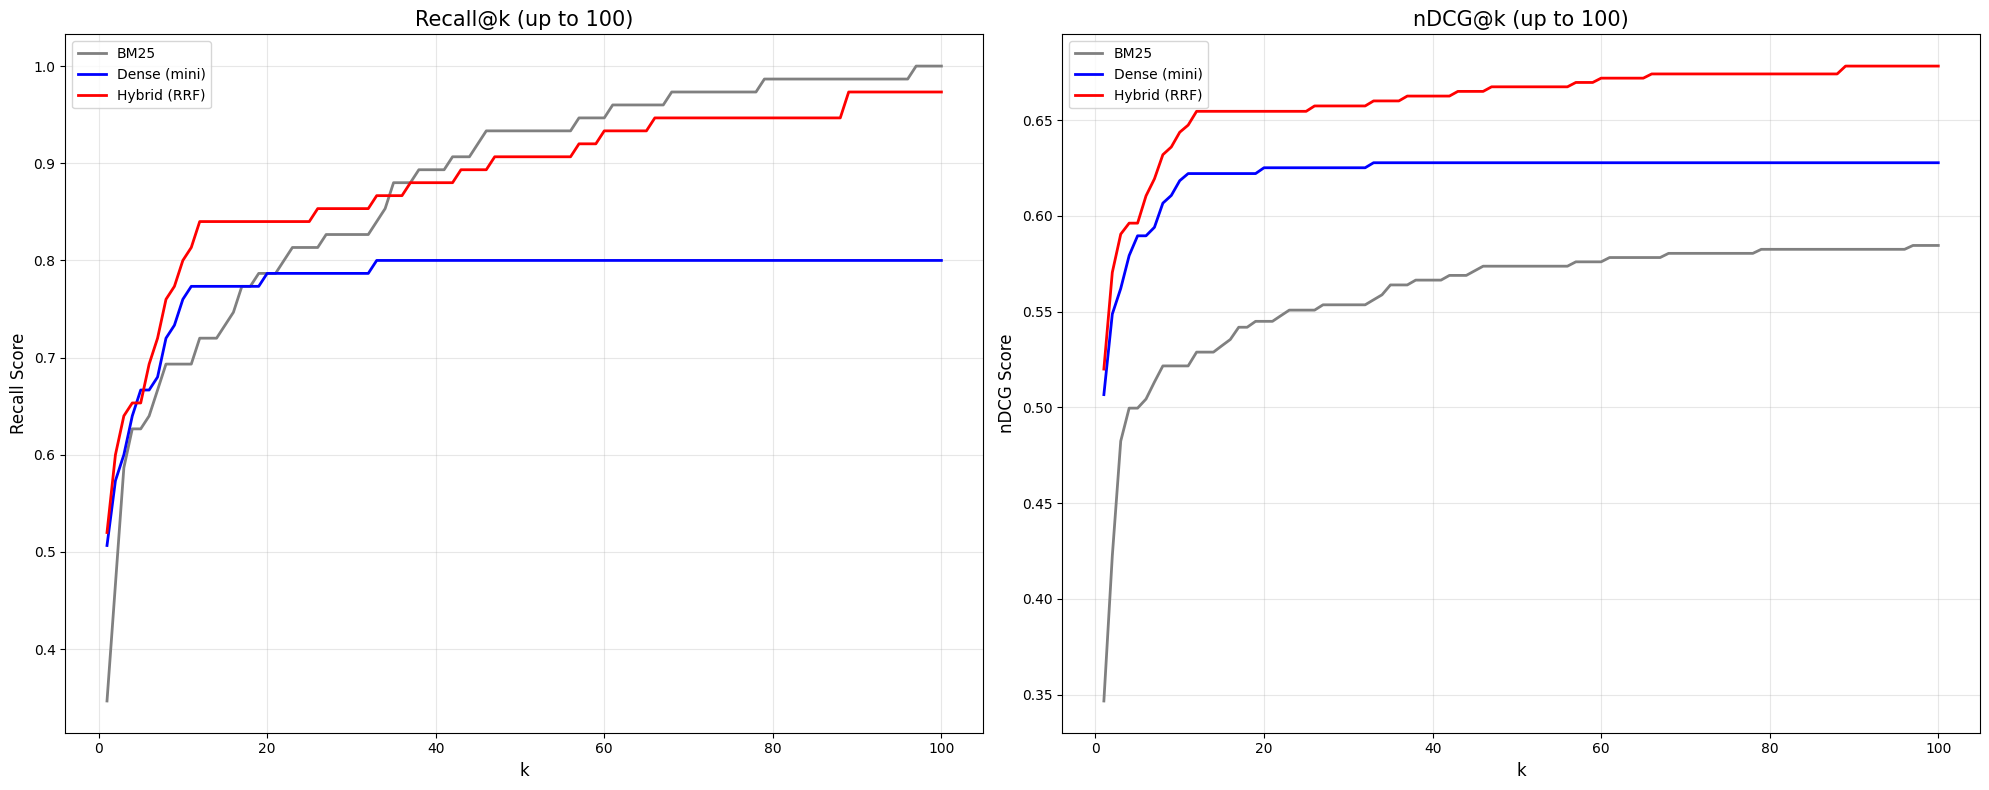

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_ndcg(results, qrels, k):
    ndcgs = []
    for qid, pred_docs in results.items():
        if qid not in qrels: continue
        
    
        actual_relevance = qrels[qid] 
        
        
        dcg = 0
        for i, doc_id in enumerate(pred_docs[:k]):
            rel = actual_relevance.get(doc_id, 0)
            dcg += (2**rel - 1) / np.log2(i + 2)
        
        
        idcg = 0
        sorted_rels = sorted(actual_relevance.values(), reverse=True)
        for i, rel in enumerate(sorted_rels[:k]):
            idcg += (2**rel - 1) / np.log2(i + 2)
            
        ndcgs.append(dcg / idcg if idcg > 0 else 0)
    return np.mean(ndcgs)

def plot_comprehensive_metrics(all_results, qrels, max_k=100):
    ks = list(range(1, max_k + 1))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    colors = {'BM25': 'gray', 'Dense (mini)': 'blue', 'Hybrid (RRF)': 'red'}

    for label, res in all_results.items():
        
        recalls = [calculate_metrics(res, qrels, k_list=[k])[f"Recall@{k}"] for k in ks]
    
        ndcgs = [calculate_ndcg(res, qrels, k) for k in ks]
        
        color = colors.get(label, None)
        ax1.plot(ks, recalls, label=f'{label}', color=color, linewidth=2)
        ax2.plot(ks, ndcgs, label=f'{label}', color=color, linewidth=2)

    
    ax1.set_title('Recall@k (up to 100)', fontsize=15)
    ax1.set_xlabel('k', fontsize=12)
    ax1.set_ylabel('Recall Score', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    
    ax2.set_title('nDCG@k (up to 100)', fontsize=15)
    ax2.set_xlabel('k', fontsize=12)
    ax2.set_ylabel('nDCG Score', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig('evaluation_metrics_mini.png', dpi=300)
    plt.show()


plot_comprehensive_metrics({
    "BM25": bm25_results,
    "Dense (mini)": dense_results_mini,
    "Hybrid (RRF)": hybrid_results_mini
}, qrels)